# Programming Assignment - Overcoming Overfitting: Building a Robust CNN

Welcome to the final assignment of this course! You have built a solid foundation in PyTorch, moving from basic tensors to a complete, working Convolutional Neural Network in a previous lab. That was an essential first step. Now, it is time to take the next step and tackle a challenge that every deep learning practitioner faces: to take a promising but flawed model and elevate it. 

Your previous model showed clear signs of overfitting, a common hurdle where a network memorizes training data instead of learning to generalize. This assignment is your mission to solve that problem, not just by tweaking a parameter, but by systematically re-engineering your entire machine learning pipeline with a suite of professional tools and techniques.

To accomplish this, you will deploy a multi-faceted strategy, upgrading every component of your setup:

* **Enhance the Data Pipeline** with more powerful data augmentation to create a richer training set.

* **Refactor the Architecture for Modularity**, creating reusable `CNNBlocks` for cleaner, more scalable code.

* **Integrate Advanced Layers** like **Batch Normalization** to stabilize training and improve generalization.

* **Deploy a Robust Regularization Strategy** using **Dropout** and **Weight Decay** to combat overfitting directly.

Let's get started and elevate your model to the next level!

---
<a name='submission'></a>

<h4 style="color:green; font-weight:bold;">TIPS FOR SUCCESSFUL GRADING OF YOUR ASSIGNMENT:</h4>

* All cells are frozen except for the ones where you need to submit your solutions or when explicitly mentioned you can interact with it.

* In each exercise cell, look for comments `### START CODE HERE ###` and `### END CODE HERE ###`. These show you where to write the solution code. **Do not add or change any code that is outside these comments**.

* You can add new cells to experiment but these will be omitted by the grader, so don't rely on newly created cells to host your solution code, use the provided places for this.

* Avoid using global variables unless you absolutely have to. The grader tests your code in an isolated environment without running all cells from the top. As a result, global variables may be unavailable when scoring your submission. Global variables that are meant to be used will be defined in UPPERCASE.

* To submit your notebook for grading, first save it by clicking the 💾 icon on the top left of the page and then click on the `Submit assignment` button on the top right of the page.
---

## Table of Contents
- [Imports](#0)
- [1 - Upgrading Your Data Pipeline](#1)
    - [1.1 - Defining More Powerful Transformations](#1-1)
        - **[Exercise 1 - define_transformations](#ex-1)**
    - [1.2 - Assembling the Data Loaders](#1-2)
    - [1.3 - Visualizing the Training Images](#1-3)
- [2 - Building a Modular and Robust CNN](#2)
    - [2.1 - The Power of Modularity: The CNNBlock](#2-1)
        - [2.1.1 - BatchNorm2d Layer](#2-1-1)
            - **[Exercise 2 - CNNBlock](#ex-2)**
    - [2.2 - Assembling the Full CNN with Modular Blocks](#2-2)
        - **[Exercise 3 - SimpleCNN](#ex-3)**
- [3 - Training the Upgraded Model](#3)
    - [3.1 - Configuring the Loss and Optimizer](#3-1)
    - [3.2 - Implementing the Training and Validation Logic](#3-2)    
        - **[Exercise 4 - train_epoch](#ex-4)**
        - **[Exercise 5 - validate_epoch](#ex-5)**        
- [4 - Beyond the Foundations: A Glimpse into the Next Level](#4)

In [17]:
import torch 
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [2]:
import helper_utils
import unittests

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
# Pre-calculated mean for each of the 3 channels of the CIFAR-100 dataset
cifar100_mean = (0.5071, 0.4867, 0.4408)
# Pre-calculated standard deviation for each of the 3 channels of the CIFAR-100 dataset
cifar100_std = (0.2675, 0.2565, 0.2761)

As you learned previously, the training transformation pipeline is where you apply data augmentation. To make your model even more robust, you will add a new technique to your arsenal this time: `RandomVerticalFlip`. While horizontal flipping is common, adding vertical flips can also help the model learn that an object's orientation might not always be upright, a useful feature for classifying things like insects or flowers from various angles.

<a name='ex-1'></a>
### Exercise 1 - define_transformations

Your task is to define two distinct image transformation pipelines using `torchvision.transforms`.

**Your Task**:

* **For `train_transformations`**: Create a composition of transforms for the training dataset.
>
    * This pipeline should include random [horizontal](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomHorizontalFlip.html) and [vertical](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomVerticalFlip.html) flips.
    * It should also randomly [rotate](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.RandomRotation.html) the images by up to **15 degrees**.
    * Finally, it must convert images to PyTorch [tensors](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html) and [normalize](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html) them using the provided `mean` and `std`.
>
* **For `val_transformations`**: Create a second, simpler pipeline for the validation dataset.
>
    * This pipeline should only perform the two essential steps: converting images to [tensors](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html) and [normalizing](https://docs.pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html) them with the same `mean` and `std`.

<details>
<summary><b><font color="green">Additional Code Hints (Click to expand if you are stuck)</font></b></summary>

If you're stuck, here is a more detailed breakdown.

You will use `transforms.Compose([...])` to create a list of transformations for both pipelines. All the required functions are part of the `transforms` module.

**For `train_transformations`**:

* You need to create a list of five transformation objects inside `transforms.Compose`.

* The first one is for horizontal flips. The call looks like this: `transforms.RandomHorizontalFlip()`.

* The next two for vertical flips and rotations follow a similar pattern. Remember to pass `15` as the argument for the rotation.

* The last two transformations are:

    * `call the ToTensor method from the transforms module`

    * `call the Normalize method from the transforms module, passing it the mean and std variables`

**For `val_transformations`**:

* This pipeline is much simpler and only contains the last two steps from the training pipeline.

* Your list inside `transforms.Compose` should contain just two items:

    * `first, the transformation to convert an image to a tensor`

    * `second, the transformation to normalize the tensor using the given mean and std`

</details>

In [10]:
def define_transformations(cifar100_mean, cifar100_std):

    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=cifar100_mean,
                            std=cifar100_std)
        
    ])

    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=cifar100_mean,
                            std=cifar100_std)
    ])

    return train_transform, val_transform


In [11]:
# Verify the Transformations
print("--- Verifying define_transformations ---\n")
train_transform_verify, val_transform_verify = define_transformations(cifar100_mean, cifar100_std)

print("Training Transformations:")
print(train_transform_verify)
print("-" * 30)
print("\nValidation Transformations:")
print(val_transform_verify)

--- Verifying define_transformations ---

Training Transformations:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)
------------------------------

Validation Transformations:
Compose(
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)


#### Expected Output:

```
Training Transformations:
Compose(
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)
------------------------------

Validation Transformations:
Compose(
    ToTensor()
    Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
)
```

In [12]:
unittests.exercise_1(define_transformations)

 All tests passed!


* Call the `define_transformations` function, passing the `cifar100_mean` and `cifar100_std` as arguments.
* This returns two separate transformation pipelines, which are stored in the `train_transform` and `val_transform` variables for later use.

In [13]:
train_transform, val_transform = define_transformations(cifar100_mean, cifar100_std)

<a name='1-2'></a>
### 1.2 - Assembling the Data Loaders

With your powerful new transformation pipelines defined, it is time to prepare the data for training. You will first specify the 15 target classes and then use your transformations to load the images and wrap them in `DataLoader` objects, which will feed the data to your model in batches.

* First, define the `all_target_classes` list.
* These are the same classes of flowers, mammals, and insects you worked with in the previous lab, ensuring you are tackling the same classification problem, but with an upgraded pipeline.

In [14]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

* Next, call the `load_cifar100_subset` function, passing in your class list (`all_target_classes`) and both transformation pipelines (`train_transform` and `val_transform`).
* This function handles the entire loading process and returns two PyTorch `Dataset` objects, which are stored in the `train_dataset` and `val_dataset` variables.

In [16]:
train_dataset, val_dataset = helper_utils.load_cifar100_subset(
    root="./data/cifar_100",
    train_transform=train_transform,
    val_transform=val_transform,
    target_classes=all_target_classes
)

Dataset found in './data/cifar_100'. Loading from local files.
Files already downloaded and verified
Files already downloaded and verified
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


<br>

With your datasets prepared, the final step is to wrap them in PyTorch's `DataLoader`. This utility is essential for feeding data to your model in manageable batches.

* Create the `train_loader` for your training data.
* Create the `val_loader` for your validation data.

In [18]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size= batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size= batch_size, shuffle=False)

<a name='1-3'></a>
### 1.3 - Visualizing the Training Images

It is always a good practice to visualize your data. The following line calls a helper function to display a grid of random images from your `train_loader`.

Pay close attention to the output. Since these images come from the training set, you should see the effects of your data augmentation pipeline in action. Look for images that have been randomly flipped horizontally, vertically, or rotated. This is an excellent way to confirm your transformations are working as expected.

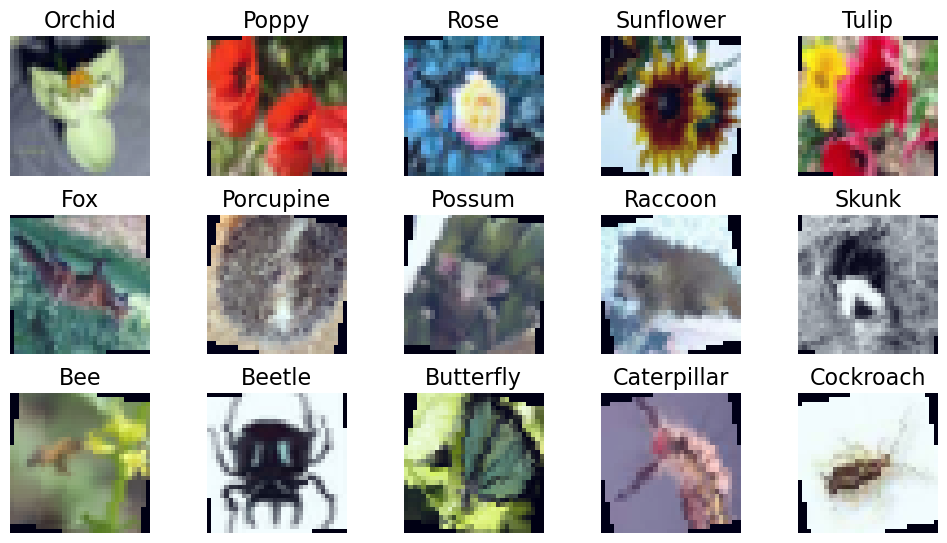

In [22]:
# Visualize a grid of random training images
helper_utils.visualise_images(train_loader, grid=(3, 5))

<a name='2'></a>
## 2 - Building a Modular and Robust CNN

With a more robust data pipeline in place, your next step is to enhance the model's architecture itself. You will refactor the original CNN to be more modular, efficient, and powerful. This is the next pivotal step toward resolving the overfitting problem and pushing your model's performance to new heights.

<a name='2-1'></a>
### 2.1 - The Power of Modularity: The CNNBlock

In the previous lab, your model's architecture had a repeating pattern of convolution, activation, and pooling layers. Defining these layers individually can become repetitive and makes the model harder to modify. A much better approach is to group these patterns into a single, reusable module. Your first task is to create a `CNNBlock` that packages these layers together. This modular design makes your main model's code significantly cleaner and easier to manage.

<a name='2-1-1'></a>
#### 2.1.1 - <code>[BatchNorm2d Layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)</code>

As part of this new, improved block, you will also introduce a powerful new layer: `BatchNorm2d`. This layer is a pivotal technique for building modern, high performing deep neural networks.

Think of Batch Normalization as a traffic controller for the data flowing between your network's layers. After a convolutional layer processes a batch of images, the outputs (or activations) can have widely varying distributions from one batch to the next. `BatchNorm2d` steps in and normalizes these activations within each mini batch, adjusting them to have a consistent mean and standard deviation. It then uses two learnable parameters to scale and shift this normalized output, allowing the network itself to learn the optimal distribution for the data at that point.

This seemingly simple step provides three profound benefits:

* **It Stabilizes and Accelerates Training**: By keeping the distribution of data consistent between layers, it prevents later layers from having to constantly adapt to a shifting input from the layers before them. This stability allows you to use higher learning rates, which can dramatically speed up how quickly your model learns.

* **It Acts as a Regularizer**: Because the normalization statistics are calculated for each unique mini batch, it introduces a slight amount of noise into the training process. This noise makes it harder for the model to perfectly memorize the training data, encouraging it to learn more general features and thus reducing overfitting.

* **It Reduces Sensitivity to Initialization**: The layer makes your model less dependent on the specific random weights it starts with, leading to more reliable and repeatable training results.

By adding `BatchNorm2d` to your `CNNBlock`, you are not just adding another layer; you are fundamentally making your model's training process more stable, efficient, and robust.

<a name='ex-2'></a>
### Exercise 2 - CNNBlock

You will now implement the `CNNBlock` class. This class will package the four layers into a single `nn.Sequential` module.

**Your Task**:

**Inside the `__init__` method**:
> * You need to define a sequential container named `self.block`.
> * Inside this <code>[nn.Sequential](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)</code> container, you will add the following layers in order:
>    1. A <code>[nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)</code> layer. Use the `in_channels`, `out_channels`, `kernel_size`, and `padding` arguments that are passed to the `__init__` method.
>    2. A <code>[nn.BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)</code> layer. This layer needs to know the number of channels of its input, which is the output of the previous convolutional layer.
>    3. A <code>[nn.ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)</code> activation function.
>    4. A <code>[nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)</code> layer. This will downsample the feature map. You should set both the `kernel_size` and `stride` to `2`.

**Inside the `forward` method**:

> * This method performs the forward pass.
> * Pass the input tensor `x` through the `self.block` you defined and return the result.

<details>
<summary><b><font color="green">Additional Code Hints (Click to expand if you are stuck)</font></b></summary>

If you are looking for more guidance, here is a detailed breakdown.

**For the `__init__` method**:

* You are defining a sequence of layers. The entire sequence will be assigned to `self.block`. The structure starts like this: `self.block = nn.Sequential(...)`.

* The layers are provided as arguments to `nn.Sequential`, separated by commas.

* **1. Convolutional Layer**: The first layer is `nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)`. Notice how it uses the parameters from the `__init__` method's signature.

* **2. Batch Norm Layer**: The second layer is `nn.BatchNorm2d(...)`. It needs one argument: the number of channels it will normalize. This is equal to the number of output channels from the previous layer, which is `out_channels`.

* **3. ReLU Layer**: The third layer is simply `nn.ReLU()`. It does not require any arguments.

* **4. Max Pooling Layer**: The final layer is `nn.MaxPool2d(...)`. You need to provide the `kernel_size` and `stride`. The call will look like: `nn.MaxPool2d(kernel_size=2, stride=2)`.

**For the `forward` method**:

* This is a single line of code. You simply need to call the module you created in the `__init__` method on the input tensor.
* The pseudocode would be: `return the result of applying self.block to the input x`.

</details>

In [23]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding= padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.block(x)

In [24]:
# Verify the CNNBlock
print("--- Verifying CNNBlock ---\n")

# Instantiate the block with 3 input channels and 16 output channels
verify_cnn_block = CNNBlock(in_channels=3, out_channels=16)
print("Block Structure:\n")
print(verify_cnn_block)

# Verify the output shape after a forward pass
# Create a dummy input tensor (batch_size=1, channels=3, height=32, width=32)
dummy_input = torch.randn(1, 3, 32, 32)
print(f"\nInput tensor shape:  {dummy_input.shape}")

# Pass the dummy tensor through the block
output = verify_cnn_block(dummy_input)
print(f"Output tensor shape: {output.shape}")

--- Verifying CNNBlock ---

Block Structure:

CNNBlock(
  (block): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

Input tensor shape:  torch.Size([1, 3, 32, 32])
Output tensor shape: torch.Size([1, 16, 16, 16])


#### Expected Output:

```
Block Structure:

CNNBlock(
  (block): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

Input tensor shape:  torch.Size([1, 3, 32, 32])
Output tensor shape: torch.Size([1, 16, 16, 16])
```

In [25]:
# Test your code!
unittests.exercise_2(CNNBlock)

 All tests passed!


<a name='2-2'></a>
### 2.2 - Assembling the Full CNN with Modular Blocks
Now that you have a reusable `CNNBlock`, you can assemble your full `SimpleCNN` architecture. By using your new modular block, you will see how much cleaner and more professional your model definition becomes. Instead of defining many individual layers for the convolutional part of your network, you will now define just three `CNNBlock` instances.

Your model will consist of two main parts:

* **A feature extractor**: A sequence of three CNNBlocks that will learn to identify visual patterns in the images.
* **A classifier**: A sequence of fully connected layers that will take the features from the convolutional blocks and make the final prediction.

In this new version, you will also increase the **dropout rate to `0.6`**. This is another important step in your fight against overfitting, as it makes the model less likely to rely on any single feature.

<a name='ex-3'></a>
### Exercise 3 - SimpleCNN

You will now implement the `__init__` and `forward` methods for the `SimpleCNN` class. You will use the `CNNBlock` you just built as the primary component of the network's body.

**Your Task**:

**Inside the `__init__` method**:

> * **Feature Extractor**:
>
>    * Instantiate three `CNNBlock` layers (`conv_block1`, `conv_block2`, `conv_block3`).
>    * The first block should take an input with **3 channels** (for RGB images) and produce **32 output channels**.
>    * For the subsequent blocks, the number of input channels must match the number of output channels from the previous block. You will double the number of channels at each step `(3 -> 32 -> 64 -> 128)`.

> * **Classifier**:
>
>    * Define a `self.classifier` using an `nn.Sequential` container.
>    * This container should have the following layers in order:
>        1. An <code>[nn.Flatten](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)</code> layer to transform the 2D feature map into a 1D vector.
>        2. An <code>[nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)</code> layer. You must calculate the correct number of input features. This depends on the output shape of the last `CNNBlock`. The output size of this layer should be **512**.
>        3. An `nn.ReLU` activation.
>        4. An <code>[nn.Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)</code> layer with a rate of `0.6` to help prevent overfitting.
>        5. A final `nn.Linear` layer that maps the **512 features** to the **number of output classes**.

**Inside the `forward` method**:
>
>    * Define the data flow through the network.
>    * Pass the input `x` sequentially through `conv_block1`, then `conv_block2`, and then `conv_block3`.
>    * Finally, pass the output of the last convolutional block through your `classifier`.
>    * Return the final output.

<details>
<summary><b><font color="green">Additional Code Hints (Click to expand if you are stuck)</font></b></summary>

If you are stuck, here is a more detailed breakdown for the implementation.

**For the `__init__` method**:

* **Convolutional Blocks**:
>    
    * The first block is a straightforward instantiation: `self.conv_block1 = CNNBlock(in_channels=3, out_channels=32)`.
    * For the second block, the `in_channels` must be `32` (the `out_channels` of the first). The `out_channels` will be `64`. Follow this pattern for the third block.
>
* **Classifier**:

    * Start by defining the sequential container: `self.classifier = nn.Sequential(...)`
    **1. Flatten Layer**: The first layer is `nn.Flatten()`. It takes no arguments.
    **2. First Linear Layer**: This is `nn.Linear(in_features=..., out_features=512)`.
        * To find the `in_features`, you need to calculate the size of the flattened tensor. The input images are 32x32. Each `CNNBlock` contains a `MaxPool2d` layer with a stride of 2, which halves the height and width. After three blocks, the dimensions will be `32 → 16 → 8 → 4`.
        * The last `CNNBlock` outputs 128 channels. So, the total number of features is `128 * 4 * 4`.
    **3. ReLU Layer**: Add `nn.ReLU()`.
    **4. Dropout Layer**: Add `nn.Dropout(0.6)`.
    **5. Final Linear Layer**: This is `nn.Linear(in_features=512, out_features=num_classes)`.

**For the `forward` method**:
>
* This method describes how data flows from input to output. You can use the same variable `x` and reassign it after each step.
* The pseudocode for the sequence is:
    * `x = pass the input x through self.conv_block1`
    * `x = pass the new x through self.conv_block2`
    * `x = pass the new x through self.conv_block3`
    * `x = pass the final feature map through self.classifier`
* Finally, return `x`.

</details>